In [1]:
import subprocess
subprocess.run(['pip', 'install', 'ase', 'pymatgen', '--break-system-packages', '-q'])

CompletedProcess(args=['pip', 'install', 'ase', 'pymatgen', '--break-system-packages', '-q'], returncode=0)

In [2]:
from pymatgen.analysis.wulff import WulffShape
from pymatgen.core import Lattice
import matplotlib.pyplot as plt
import numpy as np

# MgZn2 MEAM-relaxed hexagonal lattice
a = 5.33501
c = 8.67676
lattice = Lattice.hexagonal(a, c)

# Miller indices and surface energies (J/m²)
miller_indices = [
    (0, 0, 1),   # (001) basal
    (1, 0, 0),   # (100) prismatic
    (1, 0, 1),   # (101) pyramidal
    (1, 1, 0),   # (110) prismatic II
]

surface_energies = [
    0.7304,  # (001)
    0.6165,  # (100)
    0.6535,  # (101)
    0.6839,  # (110)
]

wulff = WulffShape(lattice, miller_indices, surface_energies)

print(f"Wulff shape summary:")
print(f"  Weighted surface energy: {wulff.weighted_surface_energy:.4f} J/m²")
print(f"  Anisotropy: {wulff.anisotropy:.4f}")
print(f"  Shape factor: {wulff.shape_factor:.4f}")

print(f"\n  {'Plane':>8} {'γ (J/m²)':>10} {'Area frac':>10}")
print("  " + "-" * 32)
for facet, energy in zip(miller_indices, surface_energies):
    area_frac = wulff.area_fraction_dict.get(tuple(facet), 0)
    print(f"  {str(facet):>8} {energy:>10.4f} {area_frac:>10.4f}")

Wulff shape summary:
  Weighted surface energy: 0.6555 J/m²
  Anisotropy: 0.0519
  Shape factor: 5.1643

     Plane   γ (J/m²)  Area frac
  --------------------------------
  (0, 0, 1)     0.7304     0.1302
  (1, 0, 0)     0.6165     0.2547
  (1, 0, 1)     0.6535     0.5699
  (1, 1, 0)     0.6839     0.0452


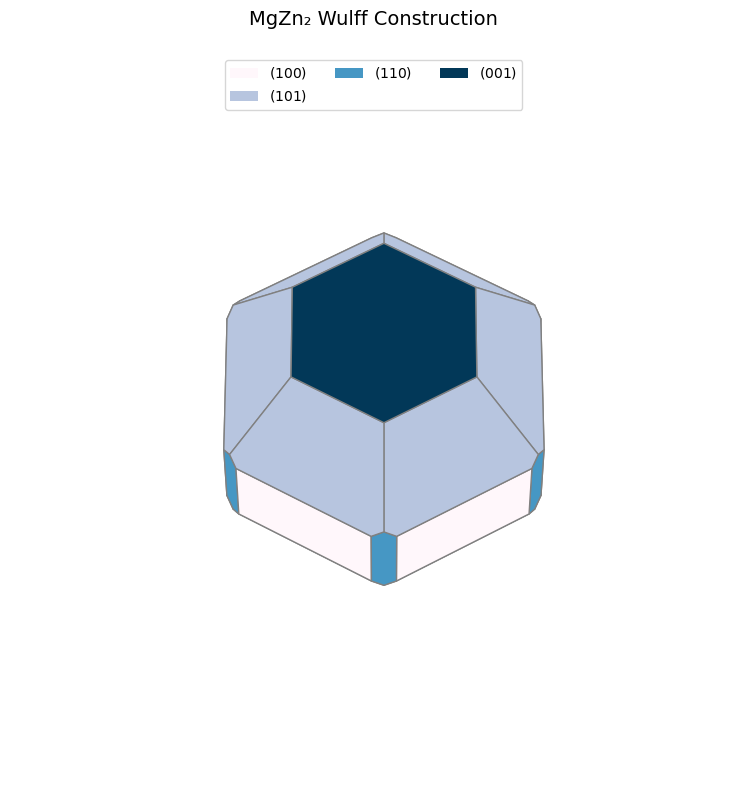

In [4]:
ax = wulff.get_plot()
fig = ax.get_figure()
fig.set_size_inches(8, 8)
plt.title("MgZn₂ Wulff Construction", fontsize=14, pad=20)
plt.tight_layout()
plt.show()